# Week 11 - Shock and vortex identification
<!-- MIE690A article-aligned validation v4 -->
**Scope:** original manufactured-field laboratory inspired by Ehsan Roohi's
*Physics-audited joint neural segmentation of shocks and vortex cores:
cross-solver transfer and controlled airfoil--cylinder studies* (author-supplied
research manuscript, 2026). Research code: https://github.com/Ehsan-Roohi/ShockVortexML.
This lab does not reproduce that network, checkpoint, CFD fields or reported scores.
The compression layer is not a Rankine--Hugoniot-consistent shock solution.

**Prerequisites:** velocity gradients (Week 1), supervised splits (Week 2),
cylinder wakes (Week 7) and gas dynamics (Week 8). Allow 75-90 minutes.
CPU only; NumPy, SciPy, scikit-learn and Matplotlib. Use Restart and Run All.
All generated fields remain in memory; no files under results/ are rewritten.

**Outcomes:** reject shear as a vortex; permit label overlap; fit preprocessing
on training cases only; choose thresholds on validation cases; report failures.
Predict first: can a large vorticity magnitude alone identify a vortex core?

**Research extension:** the final section reads real author-research evidence, clearly separated from the synthetic warm-up.
<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week11/W11_Shock_Vortex_Identification.ipynb)


In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week11"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "flowmllab" / "feature_reconstruction.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from flowmllab.feature_reconstruction import *
plt.rcParams.update({'figure.dpi': 125, 'font.size': 10})
print('Original CPU teaching analog; no research checkpoint or CFD/DSMC run.')

Original CPU teaching analog; no research checkpoint or CFD/DSMC run.


## 1. Derivatives before detection
With $A=\nabla\mathbf{u}$, compute divergence and planar vorticity.
Define $Q_d=-\frac14(u_x-v_y)^2-u_yv_x$ for the trace-free in-plane tensor.
In two dimensions $\lambda_{ci}=\sqrt{\max(Q_d,0)}$; these are not independent votes.
Do not confuse this planar diagnostic with a universal 3-D vortex definition.
Pure shear has vorticity but no swirling strength. Pure compression is not rotation.

In [2]:
x = np.linspace(-1, 1, 41)
X, Y = np.meshgrid(x, x)
h = x[1]-x[0]
controls = {'rotation': (-Y, X), 'shear': (Y, 0*X), 'compression': (-X, -Y)}
control_rows = []
for name, (u, v) in controls.items():
    d = diagnostics(u, v, h, h)
    control_rows.append({'case': name, **{k: float(d[k].mean())
                          for k in ['omega', 'swirl', 'compression']}})
display(pd.DataFrame(control_rows))
assert np.isclose(control_rows[1]['swirl'], 0)
assert np.isclose(control_rows[0]['swirl'], 1)

,case,omega,swirl,compression
0,rotation,2.0,1.0,7.304620e-17
1,shear,-1.0,0.0,3.830633e-17
2,compression,0.0,0.0,2.000000e+00


## 2. Declare entire-case splits before fitting
Each seed defines a complete analytic field: a compression-layer position and
thickness, a vortex centre and radius, a rotation sign, and a shear component.
Labels come from this construction, not thresholding the diagnostic inputs.
Training pixels may be subsampled, but no validation or test field supplies
training pixels. This is a controlled toy distribution, not solver transfer.
Shock-like layer and core labels can overlap, so no exclusive softmax is used.

In [3]:
split = {'train': list(range(10, 18)), 'validation': [30, 31], 'test': [50, 51]}
assert not (set(split['train']) & set(split['validation']) |
            set(split['train']) & set(split['test']) |
            set(split['validation']) & set(split['test']))
data = {k: [manufactured_case(i) for i in ids] for k, ids in split.items()}
print(split)

{'train': [10, 11, 12, 13, 14, 15, 16, 17], 'validation': [30, 31], 'test': [50, 51]}


## 3. Fit two independent foreground decisions with a small MLP
Eight local primitive/derivative channels enter a 32-by-24 tanh MLP.
Its two logistic outputs allow overlap. This is a pixel classifier, not the
research Harmonized Joint (HJ) multi-branch encoder-decoder, not a spatial
segmentation network, and not a PINN. The principal research model is not a U-Net.
All channels include deterministic physical information; call it a learned
diagnostic, not a physics-free model. Scaling is fitted on training pixels only.

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits
features = np.concatenate([c['features'].reshape(-1, 8)[::3] for c in data['train']])
labels = np.concatenate([c['labels'].reshape(-1, 2)[::3] for c in data['train']])
model = make_pipeline(StandardScaler(), MLPClassifier(
    hidden_layer_sizes=(32, 24), activation='tanh', solver='adam',
    max_iter=180, random_state=11, early_stopping=False))
with threadpool_limits(limits=1):
    model.fit(features, labels)
print('Optimizer iterations:', model[-1].n_iter_, 'training loss:', model[-1].loss_)
def scores(c):
    return model.predict_proba(c['features'].reshape(-1, 8)).reshape(*c['p'].shape, 2)

Optimizer iterations: 141 training loss: 0.014337018935555461


## 4. Validation-only operating points; equal treatment of the baseline
The physical baseline thresholds compression and swirling strength separately.
Both methods select one threshold per task by mean case-wise validation Dice.
Freeze those values before opening test scores; do not choose a pixel quantile
separately for every test field. A threshold sweep is not a confidence interval.

In [5]:
val = data['validation']
neural_threshold = choose_thresholds(val, [scores(c) for c in val], np.linspace(.1, .9, 9))
physical_threshold = choose_thresholds(val, [physical_scores(c) for c in val],
                                      np.linspace(.2, 5, 25))
print('Frozen MLP thresholds:', neural_threshold)
print('Frozen physical thresholds:', physical_threshold)

Frozen MLP thresholds: [0.5 0.2]
Frozen physical thresholds: [1.8 1.8]


## 5. Once-only held-out evaluation
Report each complete case, not thousands of pixels as independent replicates.
Dice is overlap, not front-location error or vortex-object recovery. We also
report connected-component counts to expose fragmentation; counts alone do not
establish one-to-one object matches. No result is required to favour the MLP.

,case,method,task,Dice,components
0,50,physical,compression layer,0.976190,1
1,50,physical,vortex core,0.962963,1
2,50,MLP,compression layer,0.925764,1
3,50,MLP,vortex core,0.877778,1
4,51,physical,compression layer,0.908686,1
5,51,physical,vortex core,0.846154,1
6,51,MLP,compression layer,0.925170,1
7,51,MLP,vortex core,0.971963,1


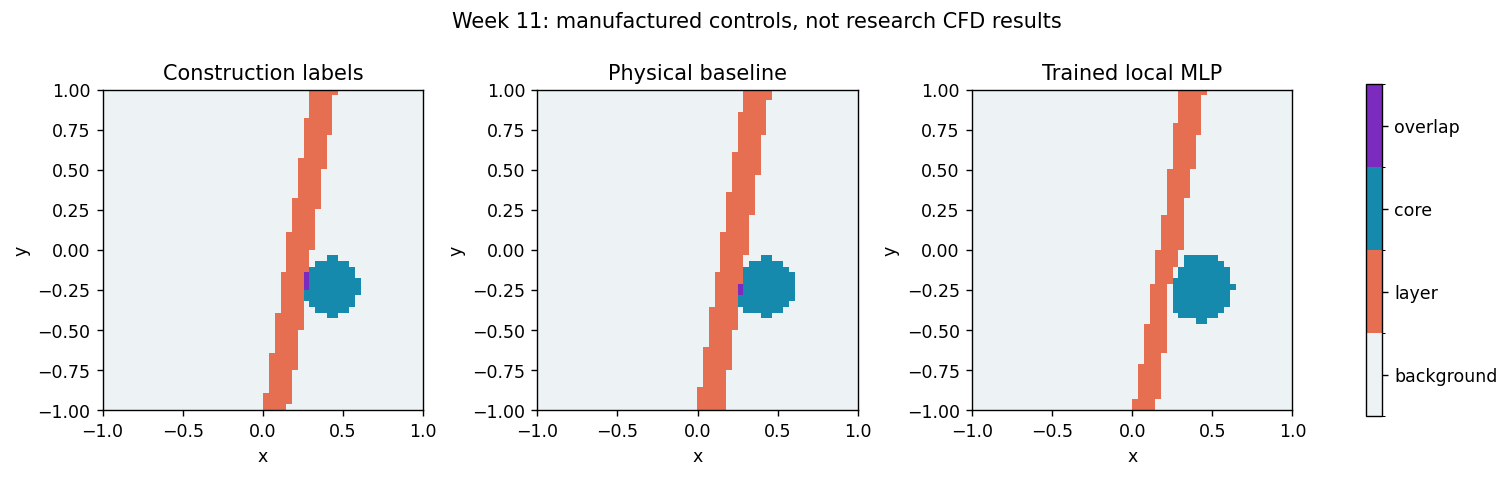

In [6]:
from scipy.ndimage import label
rows = []
for seed, c in zip(split['test'], data['test']):
    for method, pred in [('physical', physical_scores(c) >= physical_threshold),
                         ('MLP', scores(c) >= neural_threshold)]:
        for k, task in enumerate(['compression layer', 'vortex core']):
            rows.append({'case': seed, 'method': method, 'task': task,
                'Dice': dice(c['labels'][..., k], pred[..., k]),
                'components': label(pred[..., k], structure=np.ones((3,3)))[1]})
metrics = pd.DataFrame(rows)
display(metrics)
c = data['test'][0]
masks = [c['labels'], physical_scores(c) >= physical_threshold, scores(c) >= neural_threshold]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout='constrained')
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(['#edf2f4', '#e76f51', '#168aad', '#7b2cbf'])
for ax, mask, title in zip(axes, masks, ['Construction labels', 'Physical baseline', 'Trained local MLP']):
    image = ax.imshow(mask[..., 0].astype(int)+2*mask[..., 1], origin='lower',
        extent=[-1,1,-1,1], cmap=cmap, norm=BoundaryNorm(np.arange(5)-.5, 4))
    ax.set(title=title, xlabel='x', ylabel='y')
bar = fig.colorbar(image, ax=axes, ticks=[0,1,2,3], shrink=.8)
bar.ax.set_yticklabels(['background', 'layer', 'core', 'overlap'])
fig.suptitle('Week 11: manufactured controls, not research CFD results')
plt.show()

## 6. Research transfer and assignment
The research manuscript's principal Harmonized Joint (HJ) model uses a
shared encoder and specialist shock, vortex-core, wake/shear and expansion
paths with independent overlapping decisions. In task-preserving HJ shock
adaptation, the shared encoder and complete vortex path are frozen; HJ-joint
instead updates shared parameters and can damage vortex performance. A
capacity-matched U-Net is a baseline, not the main architecture. The study
also uses geometry masks, grouped trajectories and separately reported
learned/physical/hybrid products.
Its physics-derived reference masks are weak labels, not exact truth.
Supporting a hybrid output with the same proposal used to judge it creates
reference-conditioned agreement. A development-test set is not an untouched
external validation set. Do not quote this lab's Dice as article reproduction.

**Assignments:** (1) Add noisy velocities and recompute derivatives; never add
noise only to already-derived channels. (2) With new train/validation/test case
IDs, remove rotational features and report both tasks. (3) Add pure shear and
expansion controls to held-out evaluation. (4) Propose a distance-tolerant front
metric and one-to-one core matching rule. (5) Explain why freezing only the
vortex decoder does not preserve its output if the shared encoder is updated.
Preserve all failures; do not tune on the test cases above.

**Reading:** [Week 11 lecture](../../lectures/week11_shock_vortex_identification.pdf),
[ShockVortexML research repository](https://github.com/Ehsan-Roohi/ShockVortexML),
[same-model airfoil movie S2](https://www.youtube.com/watch?v=j9rO5j3sudA),
[same-model cylinder movie S8](https://www.youtube.com/watch?v=hh3K40KRBUQ).
Original FlowMLLab teaching code and analytic fields; AI-assisted authoring
and checks. Existing research data were not generated by this notebook.

## 7. Real research fields: six fresh frozen-model forward passes
These airfoil/cylinder fields already existed in Roohi's ShockVortexML
research. They were not generated by an LLM or by the manufactured lab above.
We reran the frozen research checkpoint on three preselected times per
trajectory. The first/middle/last eligible non-review frames are retained.
Research thresholds are shock=0.97 and vortex=0.85; neither was tuned here.
Human-review frames were excluded. These are previously inspected
development-test trajectories, not a fresh blind test; pixel counts are
NOT accuracy. No human ground truth, new CFD run or new training is claimed.
Full provenance and all six figures: [research gallery](../../results/week11_research/README.md).

New forward passes on previously inspected development-test CFD. No tuning, human labels, hybrid, independent accuracy or new CFD.


,dataset_id,time,shock_pixels,vortex_pixels
0,re1e6_retained_s000126900,23.50,9538,6992
1,re1e6_retained_s000153090,28.35,9609,6626
2,re1e6_retained_s000165780,30.70,9690,6766
3,cylinder_grid_f180_cfl0p20_s00004662,1.40,10187,3996
4,cylinder_grid_f180_cfl0p20_s00014985,4.50,9763,6610
5,cylinder_grid_f180_cfl0p20_s00025641,7.70,9088,5483


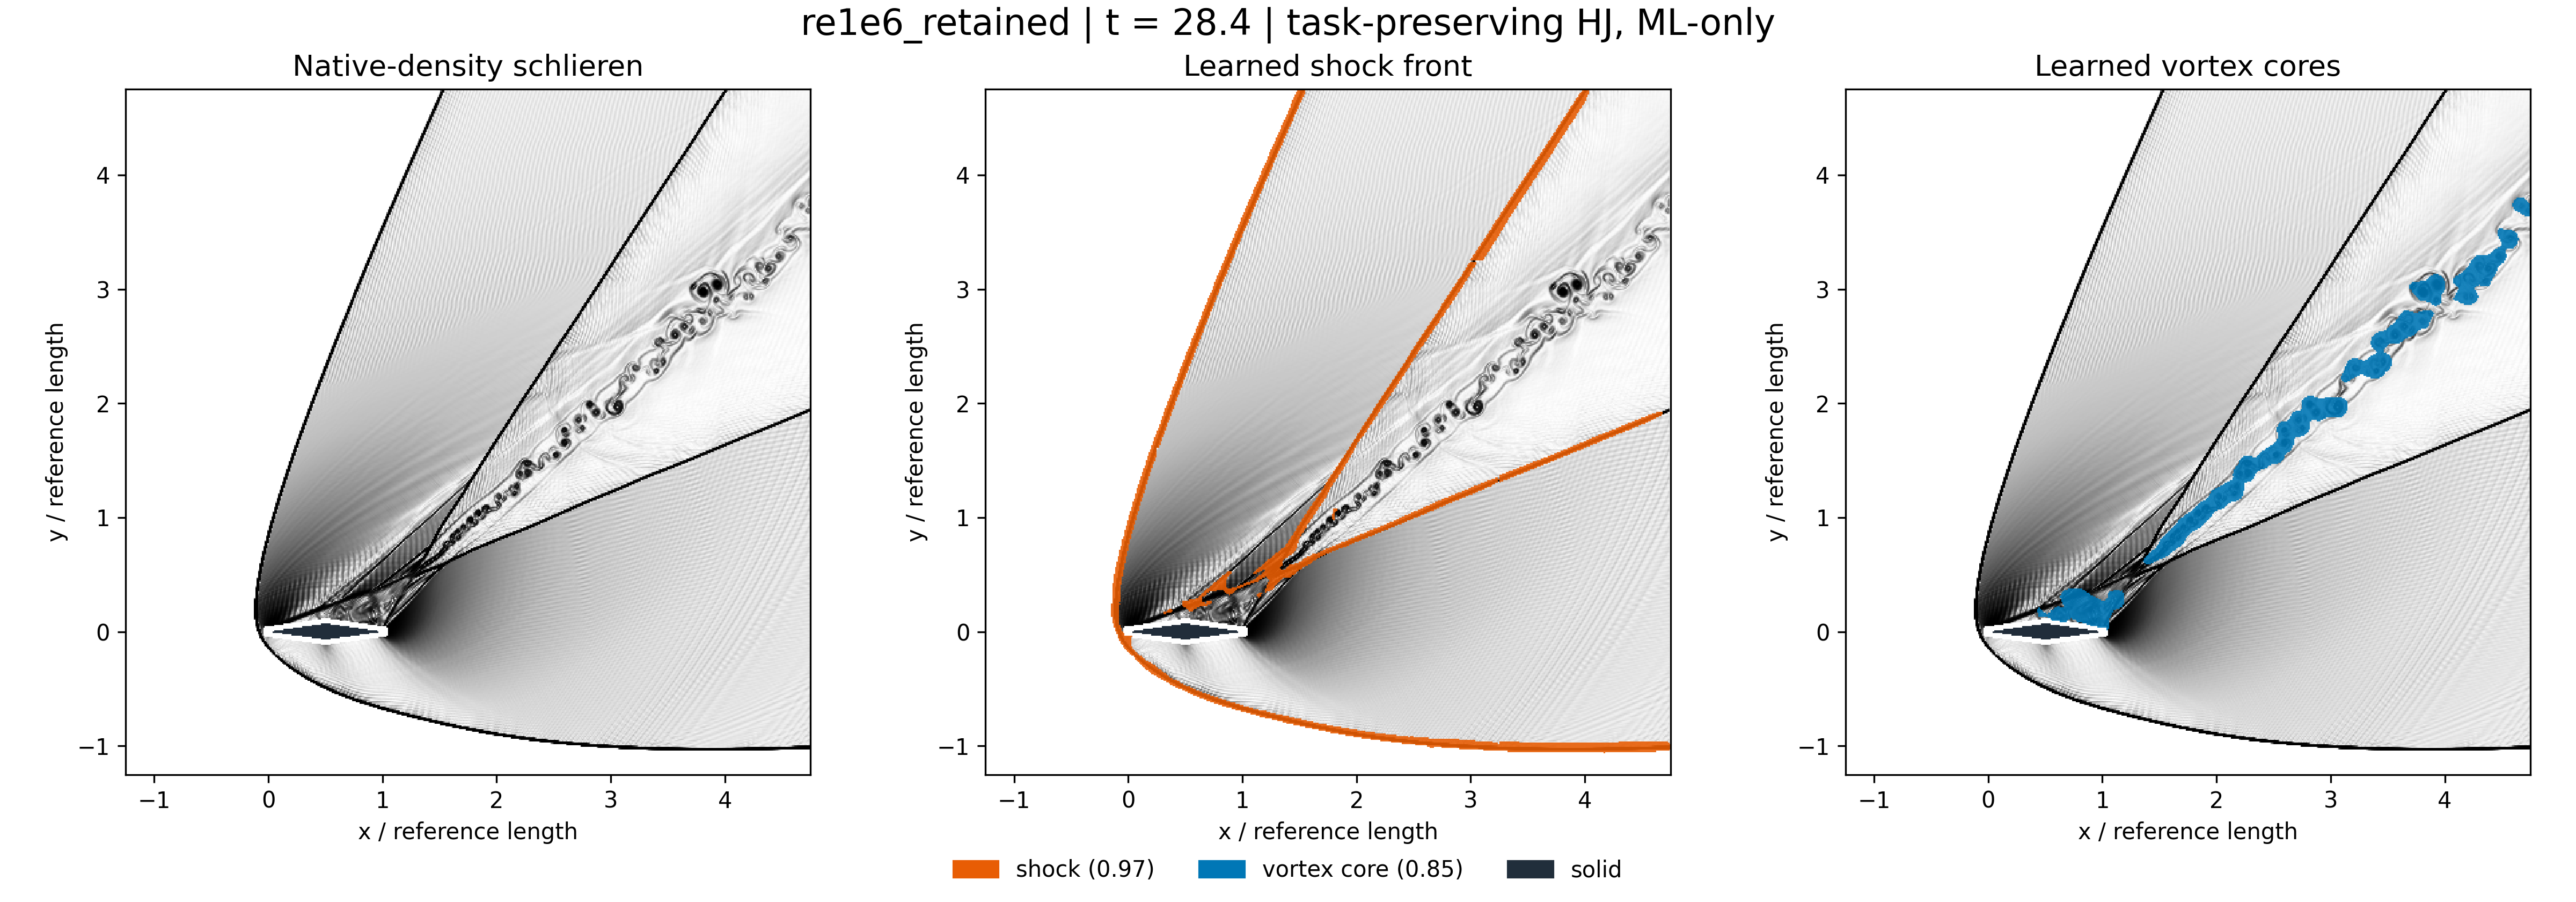

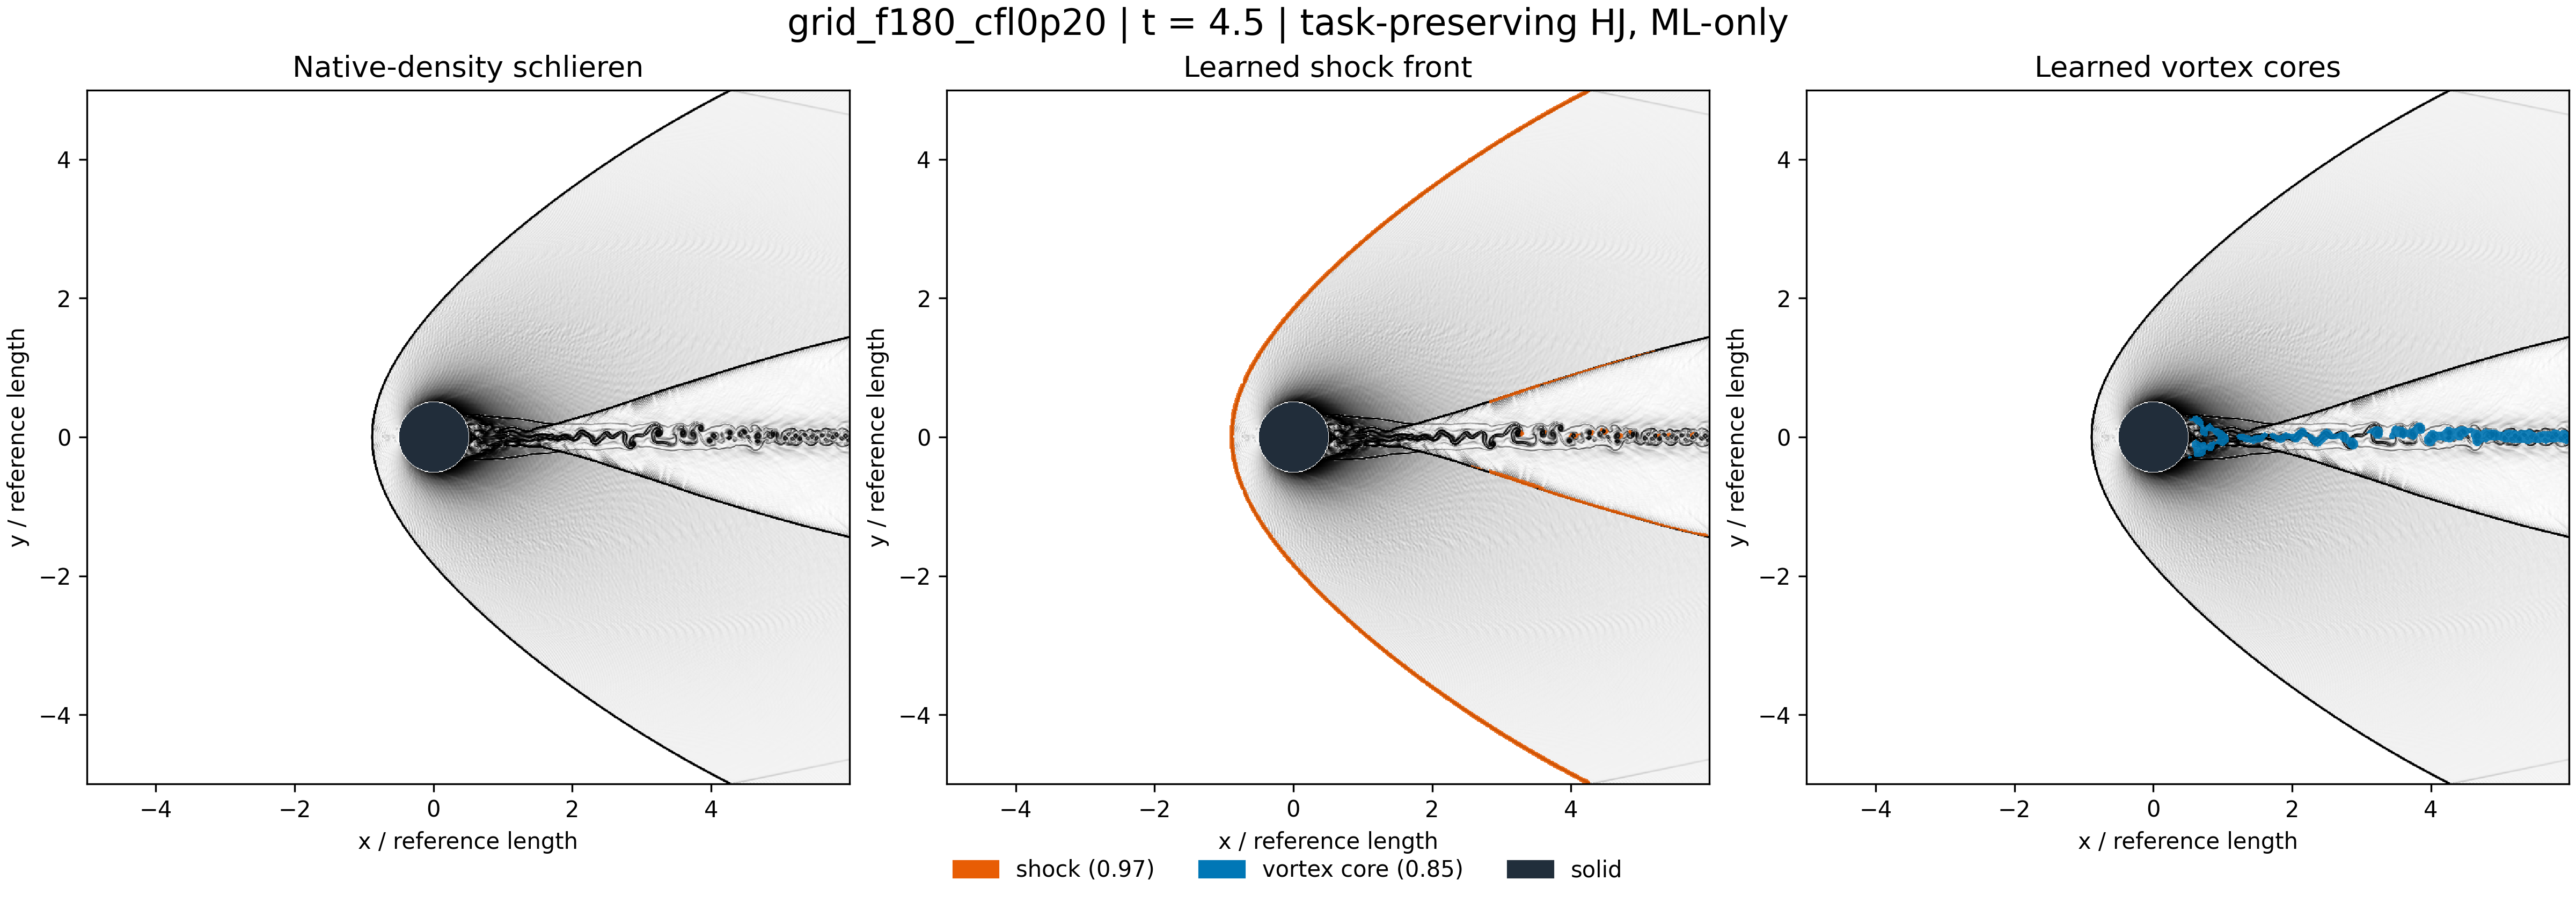

In [7]:
import json, hashlib
evidence = ROOT / 'results' / 'week11_research'
manifest = json.loads((evidence / 'research_manifest.json').read_text())
print(manifest['scope'])

for filename, sha in manifest['figure_sha256'].items():
    assert hashlib.sha256((evidence / filename).read_bytes()).hexdigest() == sha
display(pd.DataFrame(manifest['runs'])[['dataset_id','time','shock_pixels','vortex_pixels']])
from IPython.display import Image
display(Image(filename=str(evidence / 'airfoil_2.png'), width=1200))
display(Image(filename=str(evidence / 'cylinder_2.png'), width=1200))

Raw density schlieren, learned shock and learned vortex cores are separate.
No automatic shock/vortex overlap veto or physics support is added.
Inspect missed thin branches and merged cores; appearance cannot establish
accuracy. The full native domain and all three times are available.
Re-run with the author research checkout using
`python qa/run_week11_research_figures.py --research-root PATH --output NEW_SCRATCH`.
This requires the frozen replay kit, native primitives and PyTorch;
ordinary Run All reads retained evidence and does not rerun research training.